# OpenPages Revenue — Exploratory Data Analysis

**Source:** `PMC Revenue Detail (OpenPage).csv`  
**Scope:** Revenue detail rows across all geographies, customers, and quarters spanning 2024–2026  
**Metric:** `Rev Act @ PC` (Revenue Actual at Published Currency, USD)

---

### Analysis Sections
1. Data Loading & Cleaning
2. Dataset Overview
3. Revenue Trend (Quarterly)
4. Revenue by Geography & Country
5. Revenue by Product (UT L35 / SaaS vs On-Prem)
6. Revenue by Channel
7. Revenue by Coverage Type
8. Top Customers
9. Value Metric Breakdown
10. Industry Analysis
11. Key Takeaways

## 1  Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── colour palette (IBM Design Language) ────────────────────────────────────
IBM_BLUE   = '#0f62fe'
IBM_CYAN   = '#1192e8'
IBM_TEAL   = '#009d9a'
IBM_GREEN  = '#198038'
IBM_PURPLE = '#8a3ffc'
IBM_RED    = '#da1e28'
IBM_ORANGE = '#ff832b'
IBM_YELLOW = '#f1c21b'
IBM_GRAY   = '#8d8d8d'
PALETTE    = [IBM_BLUE, IBM_CYAN, IBM_TEAL, IBM_GREEN, IBM_PURPLE,
               IBM_ORANGE, IBM_RED, IBM_YELLOW, IBM_GRAY, '#6929c4']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
})

DATA_PATH = '../PMC Revenue Detail (OpenPage).csv'

# File is UTF-16 LE with tab delimiter
df = pd.read_csv(DATA_PATH, encoding='utf-16', sep='\t', low_memory=False)
print(f'Loaded  {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded  9,216 rows × 86 columns


In [2]:
# ── Tidy column names ────────────────────────────────────────────────────────
df.columns = df.columns.str.strip()

# ── Revenue column ───────────────────────────────────────────────────────────
df['Rev Act @ PC'] = pd.to_numeric(df['Rev Act @ PC'], errors='coerce')

# ── Time columns ─────────────────────────────────────────────────────────────
df['Year']    = pd.to_numeric(df['Year'],    errors='coerce').astype('Int64')
df['Quarter'] = pd.to_numeric(df['Quarter'], errors='coerce').astype('Int64')
df['Yr Qtr']  = df['Yr Qtr'].str.strip()

# ── String columns – strip whitespace ────────────────────────────────────────
str_cols = ['Geography', 'Country', 'Market', 'UT L35', 'On-prem or SaaS',
            'Revenue Type', 'Coverage type', 'Channel name', 'Customer Name',
            'Industry name (All In)', 'Value Metric', 'R4Q Period',
            'Booking Streams Category', 'Coverage Sales Vertical']
for c in str_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# ── Filter to complete / near-complete periods (exclude 'incomplete') ─────────
df_complete = df[df['R4Q Period'] != 'incomplete'].copy()
print(f'Rows after excluding incomplete periods: {len(df_complete):,}')
print(f'Rows marked incomplete (forward-looking): {(df["R4Q Period"]=="incomplete").sum():,}')

# Convenience: quarter order for plotting
qtr_order = sorted(df['Yr Qtr'].dropna().unique(),
                   key=lambda x: (x.split()[0], x.split()[-1]))
print('\nQuarters in dataset:', qtr_order)

Rows after excluding incomplete periods: 8,429
Rows marked incomplete (forward-looking): 787

Quarters in dataset: ['2024 Q1', '2024 Q2', '2024 Q3', '2024 Q4', '2025 Q1', '2025 Q2', '2025 Q3', '2025 Q4', '2026 Q1', '2026 Q2', '2026 Q3']


## 2  Dataset Overview

In [3]:
rev = df['Rev Act @ PC']
rev_complete = df_complete['Rev Act @ PC']

summary = pd.DataFrame({
    'Metric': [
        'Total rows',
        'Total Revenue (all rows)',
        'Total Revenue (excl. incomplete qtrs)',
        'Unique customers',
        'Unique countries',
        'Geographies',
        'Years',
        'Product lines (UT L35)',
        'Rows with negative revenue',
    ],
    'Value': [
        f"{len(df):,}",
        f"${rev.sum():,.0f}",
        f"${rev_complete.sum():,.0f}",
        f"{df['Customer Name'].nunique():,}",
        f"{df['Country'].nunique():,}",
        ", ".join(sorted(df['Geography'].dropna().unique())),
        ", ".join(df['Year'].dropna().astype(str).unique()),
        str(df['UT L35'].nunique()),
        f"{(rev < 0).sum():,}",
    ]
})

summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Metric,Value
Total rows,"9,216"
Total Revenue (all rows),"$71,438,393"
Total Revenue (excl. incomplete qtrs),"$65,088,637"
Unique customers,282
Unique countries,47
Geographies,"APAC, Americas, EMEA, Japan"
Years,"2024, 2025, 2026"
Product lines (UT L35),3
Rows with negative revenue,549


In [4]:
# Revenue distribution stats
df['Rev Act @ PC'].describe().rename('Rev Act @ PC ($)').to_frame().style.format('{:,.2f}')

,Rev Act @ PC ($)
count,"9,216.00"
mean,"7,751.56"
std,"90,356.29"
min,"-3,310,665.81"
25%,713.79
50%,"3,654.24"
75%,"8,367.67"
max,"3,310,665.81"


## 3  Revenue Trend (Quarterly)

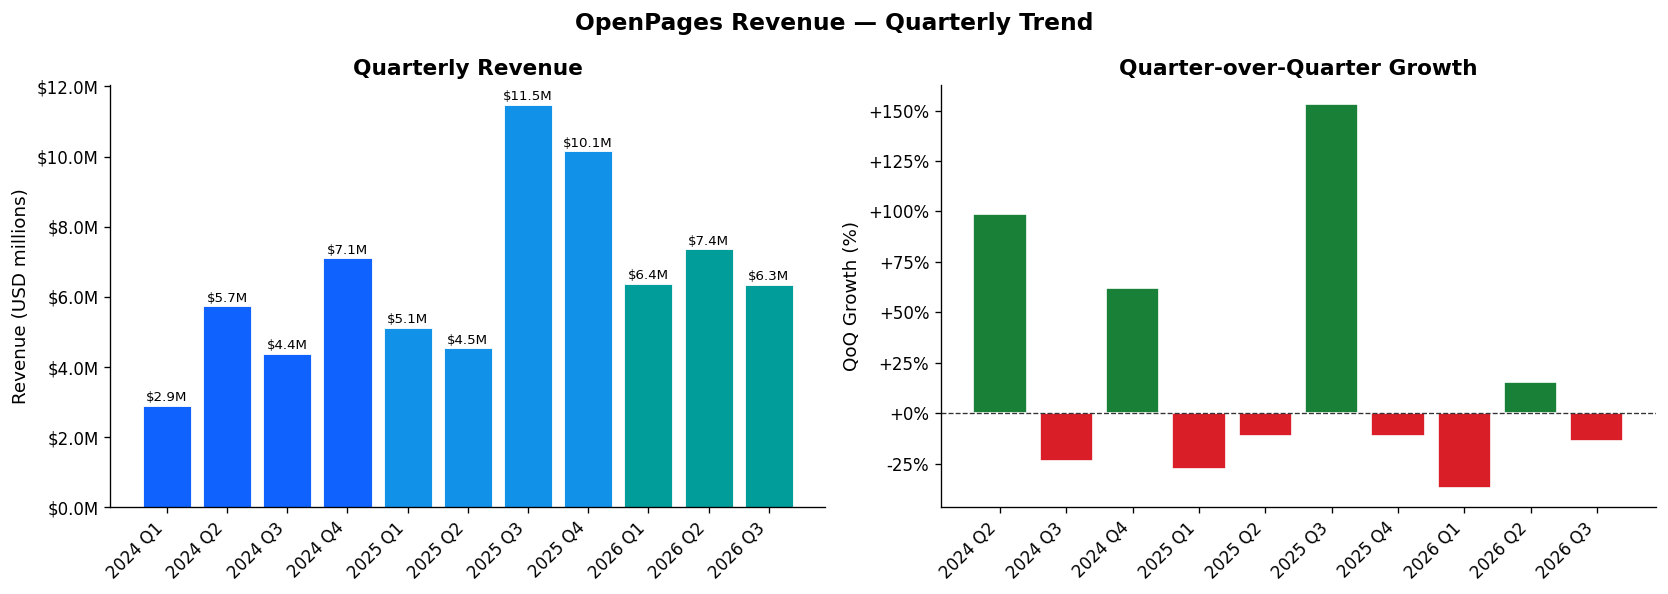


Quarterly Revenue Table:


,Revenue,QoQ %
Yr Qtr,,
2024 Q1,"$2,882,115",+nan%
2024 Q2,"$5,729,963",+98.8%
2024 Q3,"$4,380,401",-23.6%
2024 Q4,"$7,098,706",+62.1%
2025 Q1,"$5,120,432",-27.9%
2025 Q2,"$4,530,240",-11.5%
2025 Q3,"$11,469,190",+153.2%
2025 Q4,"$10,147,460",-11.5%
2026 Q1,"$6,377,179",-37.2%


In [5]:
qtr_rev = (
    df.groupby('Yr Qtr')['Rev Act @ PC']
    .sum()
    .reindex(qtr_order)
)

# Rolling 4-quarter total
qtr_rev_r4q = qtr_rev.rolling(4).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('OpenPages Revenue — Quarterly Trend', fontweight='bold')

# Bar chart
ax = axes[0]
bars = ax.bar(range(len(qtr_rev)), qtr_rev.values / 1e6,
              color=[IBM_BLUE if '2024' in q else IBM_CYAN if '2025' in q else IBM_TEAL
                     for q in qtr_rev.index],
              edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(qtr_rev)))
ax.set_xticklabels(qtr_rev.index, rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.set_title('Quarterly Revenue')
ax.set_ylabel('Revenue (USD millions)')
# Value labels
for i, v in enumerate(qtr_rev.values):
    ax.text(i, v/1e6 + 0.05, f'${v/1e6:.1f}M', ha='center', va='bottom', fontsize=8)

# QoQ growth line
ax2 = axes[1]
qoq = qtr_rev.pct_change() * 100
colors_line = [IBM_GREEN if v >= 0 else IBM_RED for v in qoq.values[1:]]
ax2.bar(range(1, len(qoq)), qoq.values[1:], color=colors_line, edgecolor='white')
ax2.axhline(0, color='#333', linewidth=0.8, linestyle='--')
ax2.set_xticks(range(1, len(qoq)))
ax2.set_xticklabels(qtr_rev.index[1:], rotation=45, ha='right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax2.set_title('Quarter-over-Quarter Growth')
ax2.set_ylabel('QoQ Growth (%)')

plt.tight_layout()
plt.show()

print('\nQuarterly Revenue Table:')
display(
    qtr_rev.rename('Revenue').to_frame()
    .assign(**{'QoQ %': qoq.round(1)})
    .style.format({'Revenue': '${:,.0f}', 'QoQ %': '{:+.1f}%'})
)

## 4  Revenue by Geography & Country

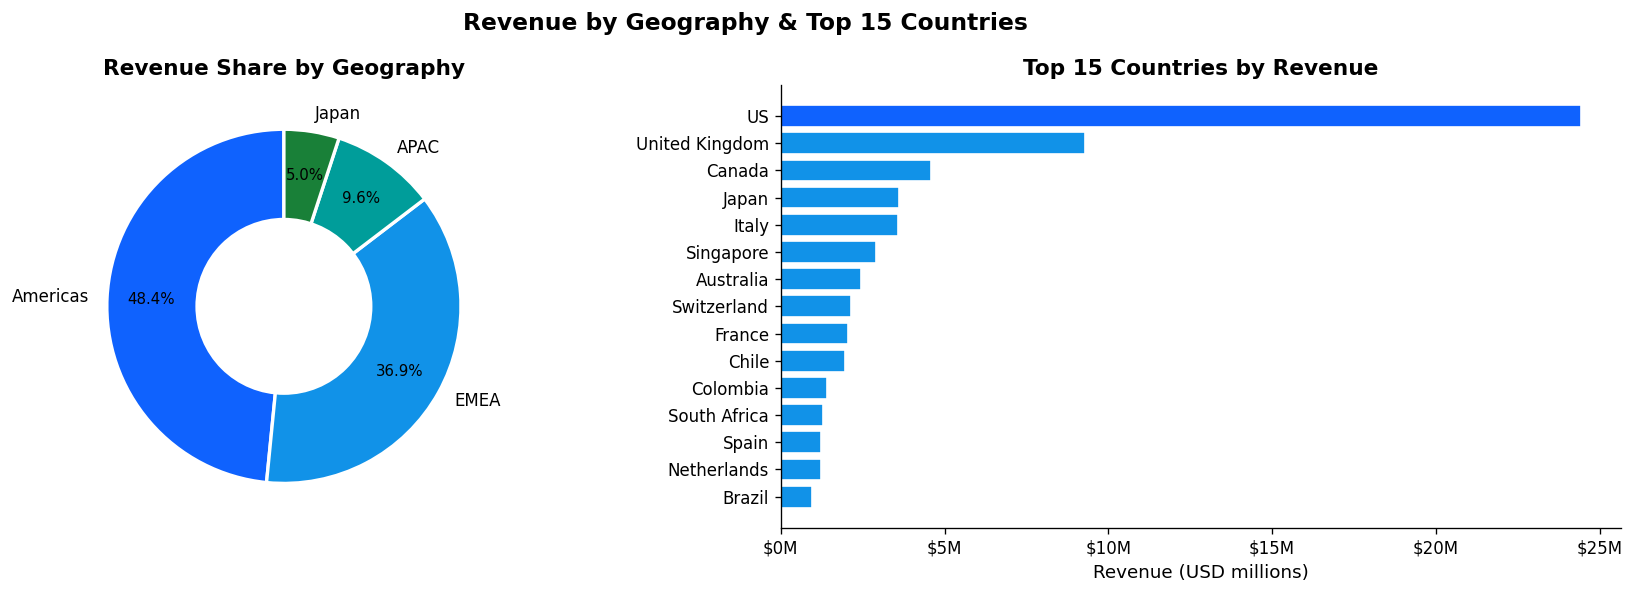


Geography Revenue:


,Revenue,Share
Geography,,
Americas,"$34,600,940",48.4%
EMEA,"$26,386,006",36.9%
APAC,"$6,850,527",9.6%
Japan,"$3,600,920",5.0%


In [6]:
geo_rev = df.groupby('Geography')['Rev Act @ PC'].sum().sort_values(ascending=False)
country_rev = df.groupby('Country')['Rev Act @ PC'].sum().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Revenue by Geography & Top 15 Countries', fontweight='bold')

# Geo donut
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    geo_rev.values,
    labels=geo_rev.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=PALETTE[:len(geo_rev)],
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    pctdistance=0.75
)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax.add_artist(centre_circle)
ax.set_title('Revenue Share by Geography')
for t in autotexts:
    t.set_fontsize(9)

# Country bar
ax2 = axes[1]
colors_c = [IBM_BLUE if c == 'US' else IBM_CYAN for c in country_rev.index]
ax2.barh(country_rev.index[::-1], country_rev.values[::-1] / 1e6,
         color=colors_c[::-1], edgecolor='white')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax2.set_title('Top 15 Countries by Revenue')
ax2.set_xlabel('Revenue (USD millions)')

plt.tight_layout()
plt.show()

print('\nGeography Revenue:')
display(
    geo_rev.rename('Revenue').to_frame()
    .assign(Share=lambda d: (d['Revenue'] / d['Revenue'].sum() * 100).round(1))
    .style.format({'Revenue': '${:,.0f}', 'Share': '{:.1f}%'})
)

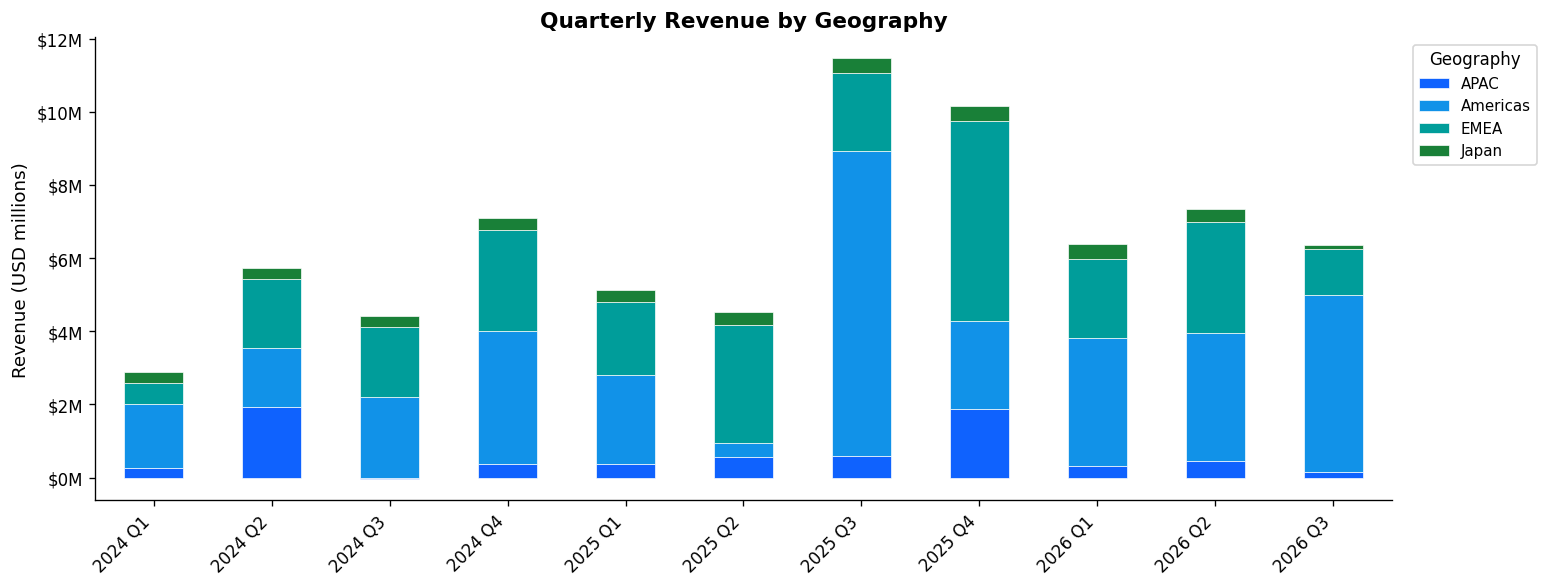

In [7]:
# Geography revenue over time
geo_qtr = (
    df.groupby(['Yr Qtr', 'Geography'])['Rev Act @ PC']
    .sum()
    .unstack('Geography')
    .reindex(qtr_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(13, 5))
geo_qtr.div(1e6).plot(kind='bar', stacked=True, ax=ax,
                       color=PALETTE[:geo_qtr.shape[1]], edgecolor='white', linewidth=0.4)
ax.set_title('Quarterly Revenue by Geography')
ax.set_ylabel('Revenue (USD millions)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.legend(title='Geography', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5  Revenue by Product Line (SaaS vs. On-Prem)

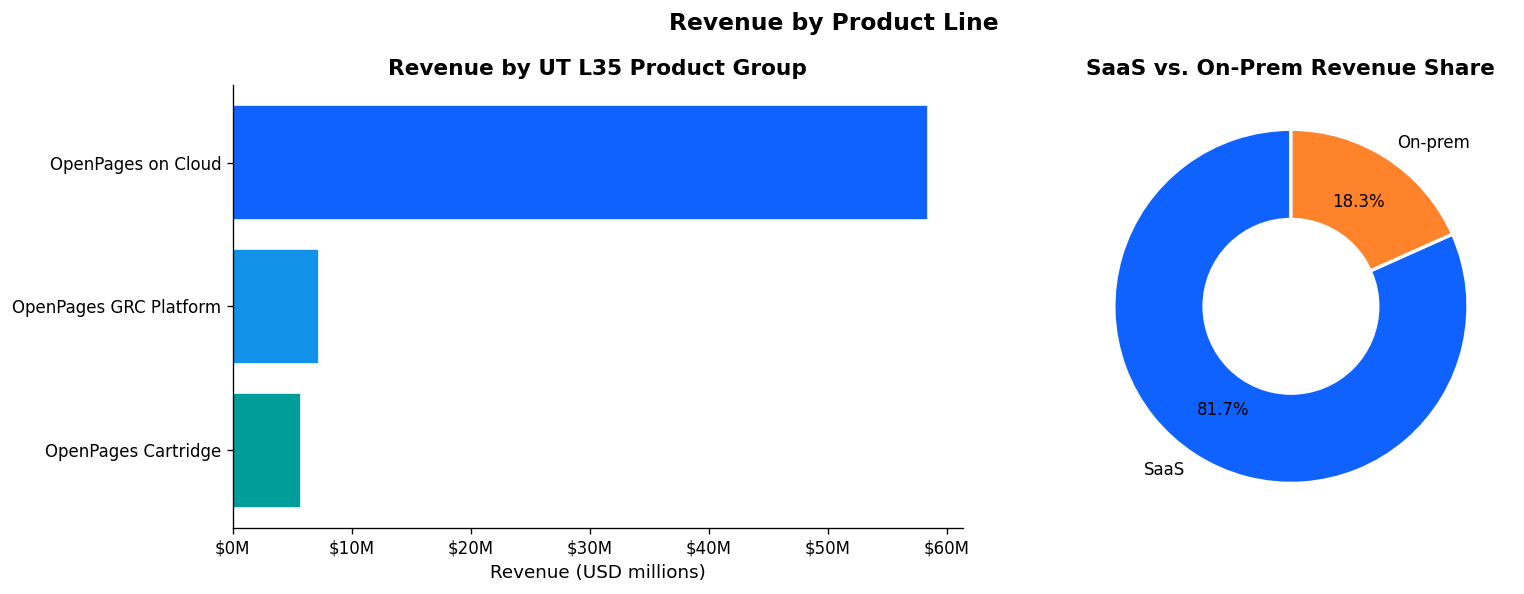

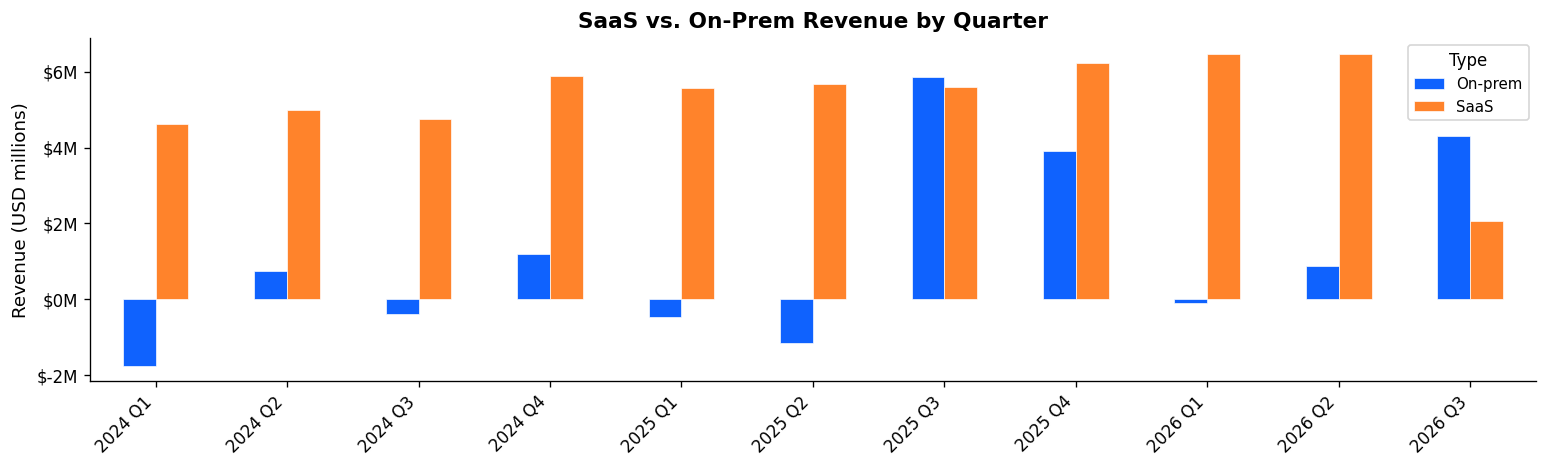

In [8]:
utl35_rev = df.groupby('UT L35')['Rev Act @ PC'].sum().sort_values(ascending=False)
saas_rev  = df.groupby('On-prem or SaaS')['Rev Act @ PC'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue by Product Line', fontweight='bold')

# UT L35 bars
ax = axes[0]
ax.barh(utl35_rev.index[::-1], utl35_rev.values[::-1] / 1e6,
        color=PALETTE[:len(utl35_rev)][::-1], edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_title('Revenue by UT L35 Product Group')
ax.set_xlabel('Revenue (USD millions)')

# SaaS vs On-prem
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    saas_rev.values,
    labels=saas_rev.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[IBM_BLUE, IBM_ORANGE],
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    pctdistance=0.70
)
centre = plt.Circle((0, 0), 0.50, fc='white')
ax2.add_artist(centre)
ax2.set_title('SaaS vs. On-Prem Revenue Share')

plt.tight_layout()
plt.show()

# SaaS trend over time
saas_qtr = (
    df.groupby(['Yr Qtr', 'On-prem or SaaS'])['Rev Act @ PC']
    .sum()
    .unstack('On-prem or SaaS')
    .reindex(qtr_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(13, 4))
saas_qtr.div(1e6).plot(kind='bar', ax=ax, color=[IBM_BLUE, IBM_ORANGE],
                       edgecolor='white', linewidth=0.4)
ax.set_title('SaaS vs. On-Prem Revenue by Quarter')
ax.set_ylabel('Revenue (USD millions)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.legend(title='Type')
plt.tight_layout()
plt.show()

## 6  Revenue by Channel

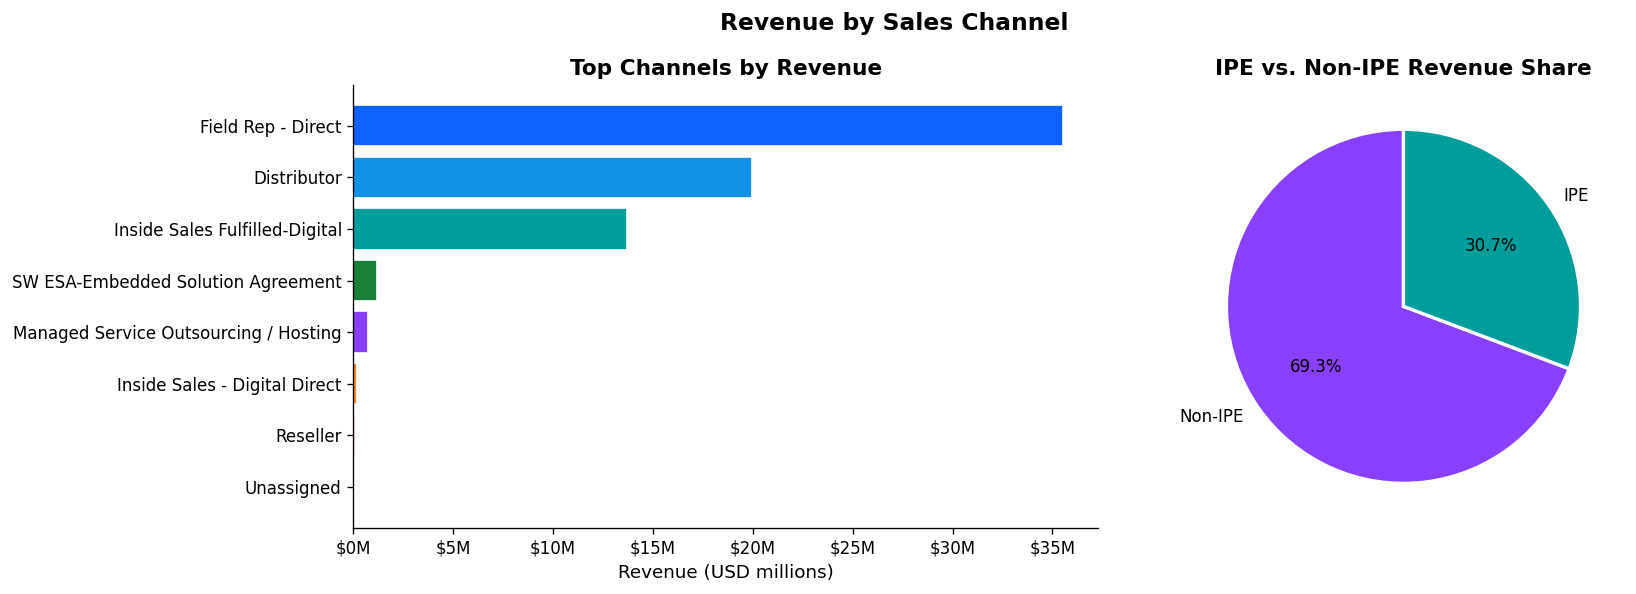


Revenue by Channel Sub-Group:


,Revenue,Share
Channel Sub Group,,
Field Sales,"$35,525,711",49.7%
Business Partner Channels,"$21,955,032",30.7%
Digital Sales Other,"$13,721,483",19.2%
Digital Sales,"$196,542",0.3%
Unassigned,"$39,625",0.1%


In [9]:
chan_rev = (
    df.groupby('Channel name')['Rev Act @ PC']
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Revenue by Sales Channel', fontweight='bold')

# Horizontal bar
ax = axes[0]
ax.barh(chan_rev.index[::-1], chan_rev.values[::-1] / 1e6,
        color=PALETTE[:len(chan_rev)][::-1], edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_title('Top Channels by Revenue')
ax.set_xlabel('Revenue (USD millions)')

# IPE vs Non-IPE
ipe_rev = df.groupby('IPE/non-IPE')['Rev Act @ PC'].sum().sort_values(ascending=False)
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    ipe_rev.values,
    labels=ipe_rev.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[IBM_PURPLE, IBM_TEAL],
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
)
ax2.set_title('IPE vs. Non-IPE Revenue Share')

plt.tight_layout()
plt.show()

# Channel sub-group
chsub_rev = (
    df.groupby('Channel Sub Group')['Rev Act @ PC']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
print('\nRevenue by Channel Sub-Group:')
display(
    chsub_rev.rename('Revenue').to_frame()
    .assign(Share=lambda d: (d['Revenue'] / d['Revenue'].sum() * 100).round(1))
    .style.format({'Revenue': '${:,.0f}', 'Share': '{:.1f}%'})
)

## 7  Revenue by Coverage Type

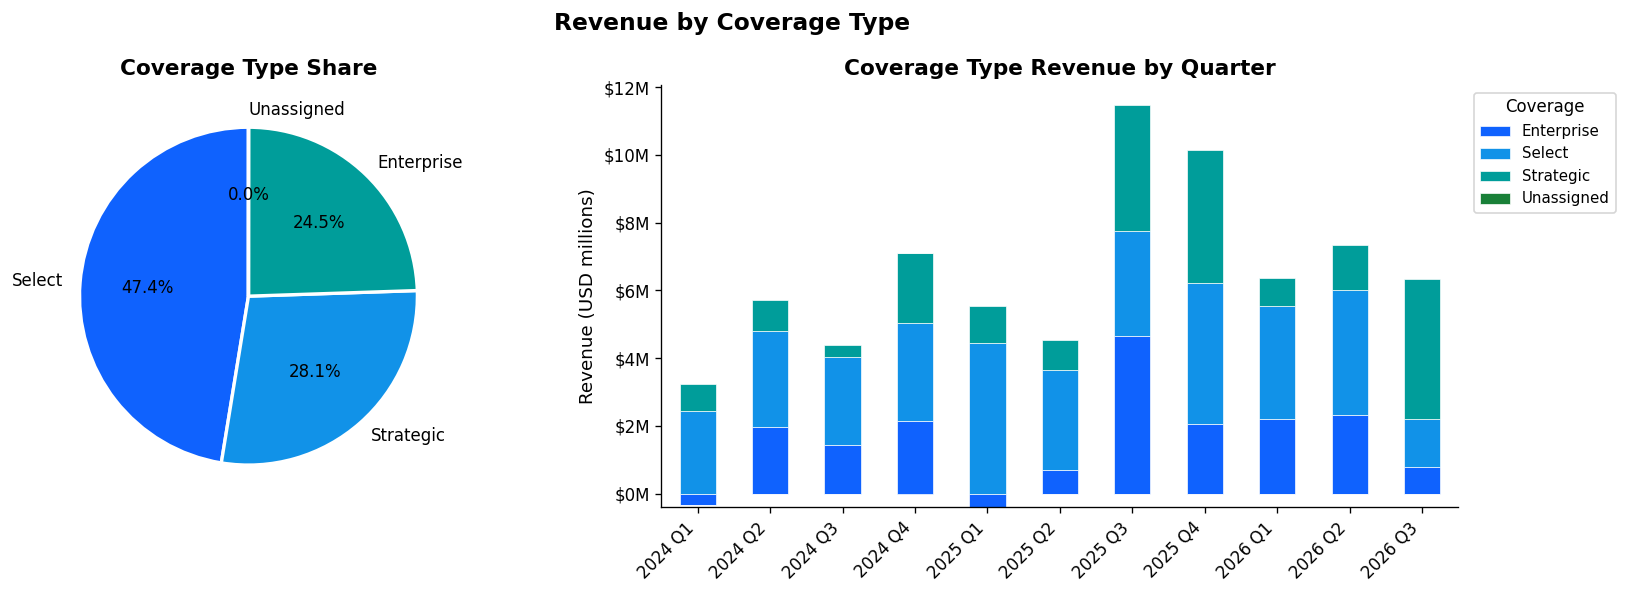

In [10]:
cov_rev = df.groupby('Coverage type')['Rev Act @ PC'].sum().sort_values(ascending=False)

# Coverage type trend over time
cov_qtr = (
    df.groupby(['Yr Qtr', 'Coverage type'])['Rev Act @ PC']
    .sum()
    .unstack('Coverage type')
    .reindex(qtr_order)
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Revenue by Coverage Type', fontweight='bold')

ax = axes[0]
wedges, texts, autotexts = ax.pie(
    cov_rev.values,
    labels=cov_rev.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=PALETTE[:len(cov_rev)],
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
)
ax.set_title('Coverage Type Share')

ax2 = axes[1]
cov_qtr.div(1e6).plot(kind='bar', stacked=True, ax=ax2,
                       color=PALETTE[:cov_qtr.shape[1]], edgecolor='white', linewidth=0.4)
ax2.set_title('Coverage Type Revenue by Quarter')
ax2.set_ylabel('Revenue (USD millions)')
ax2.set_xlabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax2.legend(title='Coverage', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8  Top Customers

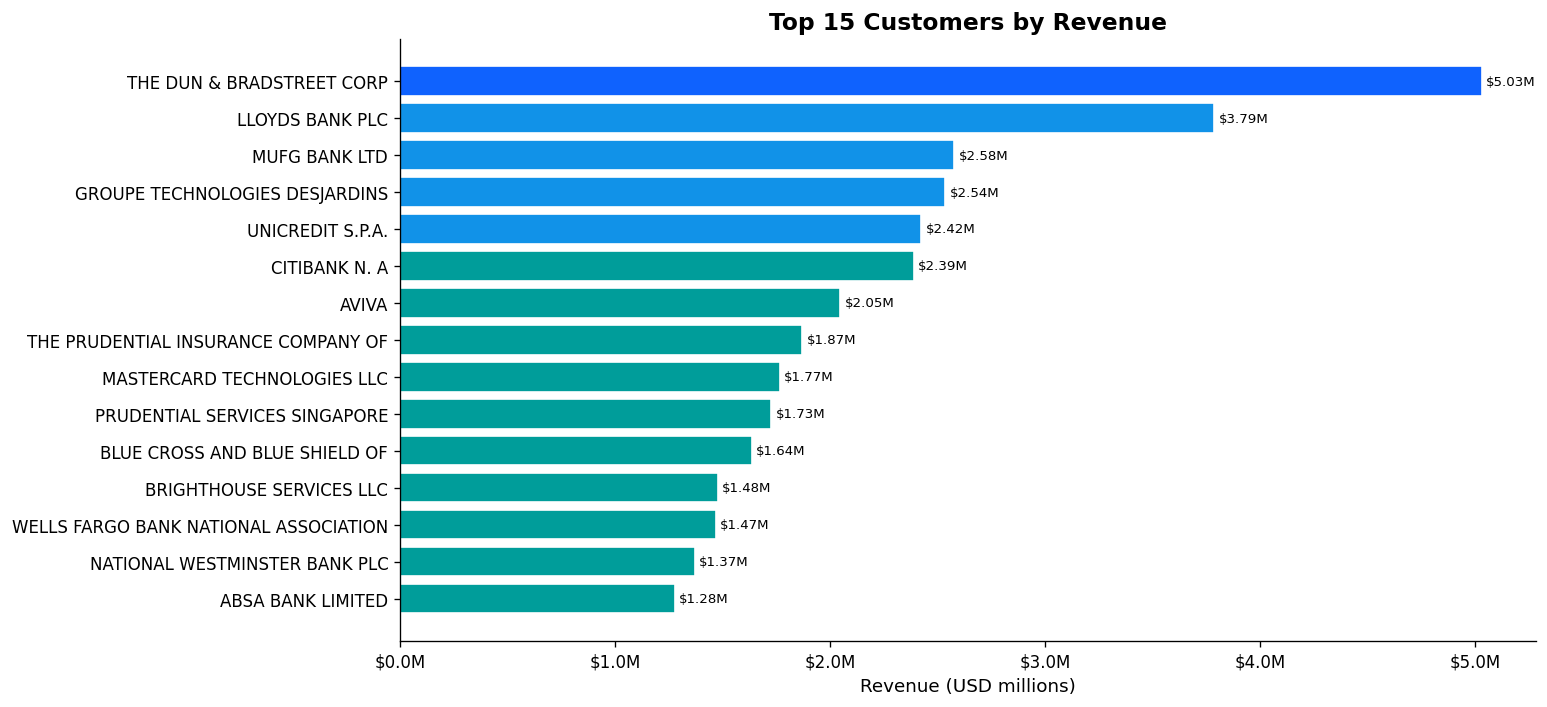

Top 5  customers account for  22.9% of total revenue
Top 10 customers account for 36.6% of total revenue


,Revenue,Share
Customer Name,,
THE DUN & BRADSTREET CORP,"$5,031,099",7.04%
LLOYDS BANK PLC,"$3,785,966",5.30%
MUFG BANK LTD,"$2,576,874",3.61%
GROUPE TECHNOLOGIES DESJARDINS,"$2,536,721",3.55%
UNICREDIT S.P.A.,"$2,423,720",3.39%
CITIBANK N. A,"$2,390,418",3.35%
AVIVA,"$2,047,691",2.87%
THE PRUDENTIAL INSURANCE COMPANY OF,"$1,871,736",2.62%
MASTERCARD TECHNOLOGIES LLC,"$1,766,464",2.47%


In [11]:
top_customers = (
    df.groupby('Customer Name')['Rev Act @ PC']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(13, 6))
bar_colors = [IBM_BLUE] + [IBM_CYAN] * 4 + [IBM_TEAL] * 10
ax.barh(top_customers.index[::-1], top_customers.values[::-1] / 1e6,
        color=bar_colors[::-1], edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.set_title('Top 15 Customers by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (USD millions)')
# Add value labels
for i, v in enumerate(top_customers.values[::-1]):
    ax.text(v/1e6 + 0.02, i, f'${v/1e6:.2f}M', va='center', fontsize=8)
plt.tight_layout()
plt.show()

# Concentration stats
total_rev = df['Rev Act @ PC'].sum()
top5_share  = top_customers.head(5).sum()  / total_rev * 100
top10_share = top_customers.head(10).sum() / total_rev * 100
print(f'Top 5  customers account for  {top5_share:.1f}% of total revenue')
print(f'Top 10 customers account for {top10_share:.1f}% of total revenue')

# Table
display(
    top_customers.rename('Revenue').to_frame()
    .assign(Share=lambda d: (d['Revenue'] / total_rev * 100).round(2))
    .style.format({'Revenue': '${:,.0f}', 'Share': '{:.2f}%'})
)

## 9  Value Metric Breakdown

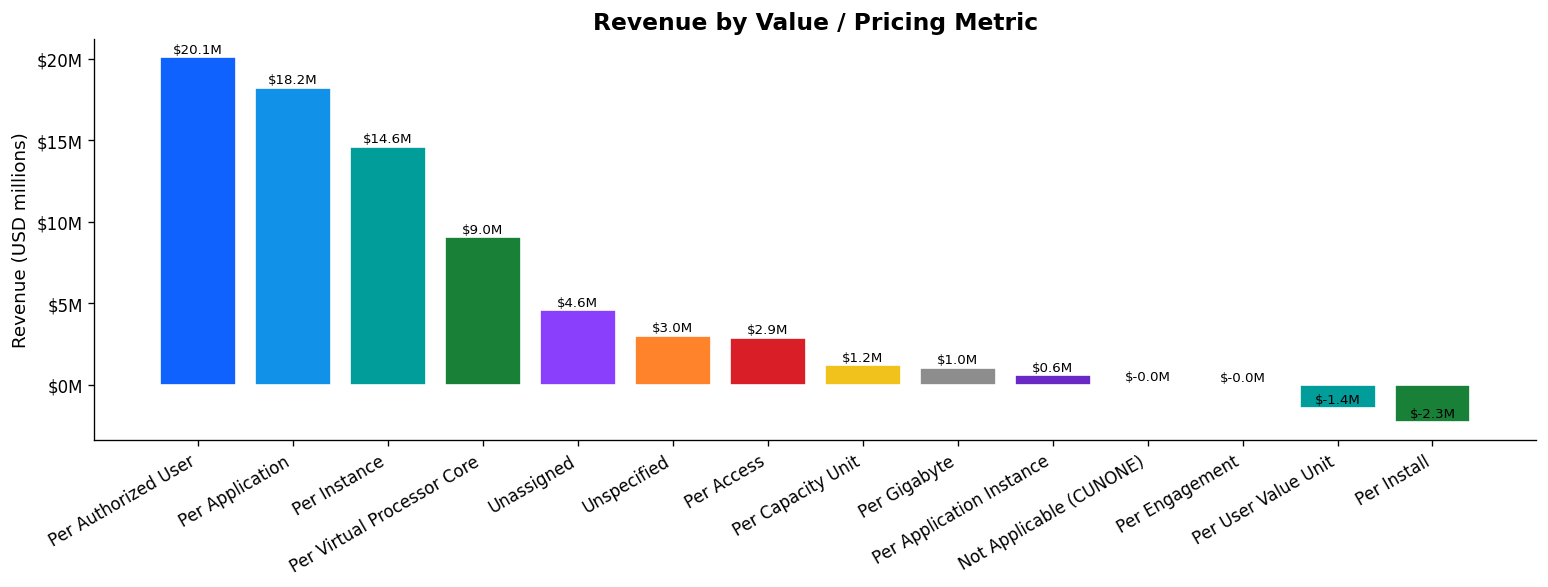


Value Metric Revenue Table:


,Revenue,Share
Value Metric,,
Per Authorized User,"$20,090,208",28.1%
Per Application,"$18,212,031",25.5%
Per Instance,"$14,603,336",20.4%
Per Virtual Processor Core,"$9,034,107",12.6%
Unassigned,"$4,570,143",6.4%
Unspecified,"$2,997,607",4.2%
Per Access,"$2,856,559",4.0%
Per Capacity Unit,"$1,189,176",1.7%
Per Gigabyte,"$1,049,020",1.5%


In [12]:
vm_rev = (
    df.groupby('Value Metric')['Rev Act @ PC']
    .sum()
    .sort_values(ascending=False)
)
# Replace blank / 'nan'
vm_rev.index = vm_rev.index.str.replace('^$', 'Unspecified', regex=True)
vm_rev.index = vm_rev.index.str.replace('^nan$', 'Unspecified', regex=True)
vm_rev = vm_rev.groupby(vm_rev.index).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(vm_rev.index, vm_rev.values / 1e6, color=PALETTE[:len(vm_rev)], edgecolor='white')
ax.set_title('Revenue by Value / Pricing Metric', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (USD millions)')
ax.set_xticklabels(vm_rev.index, rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
for bar, v in zip(bars, vm_rev.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'${v/1e6:.1f}M', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print('\nValue Metric Revenue Table:')
display(
    vm_rev.rename('Revenue').to_frame()
    .assign(Share=lambda d: (d['Revenue'] / d['Revenue'].sum() * 100).round(1))
    .style.format({'Revenue': '${:,.0f}', 'Share': '{:.1f}%'})
)

## 10  Industry Analysis

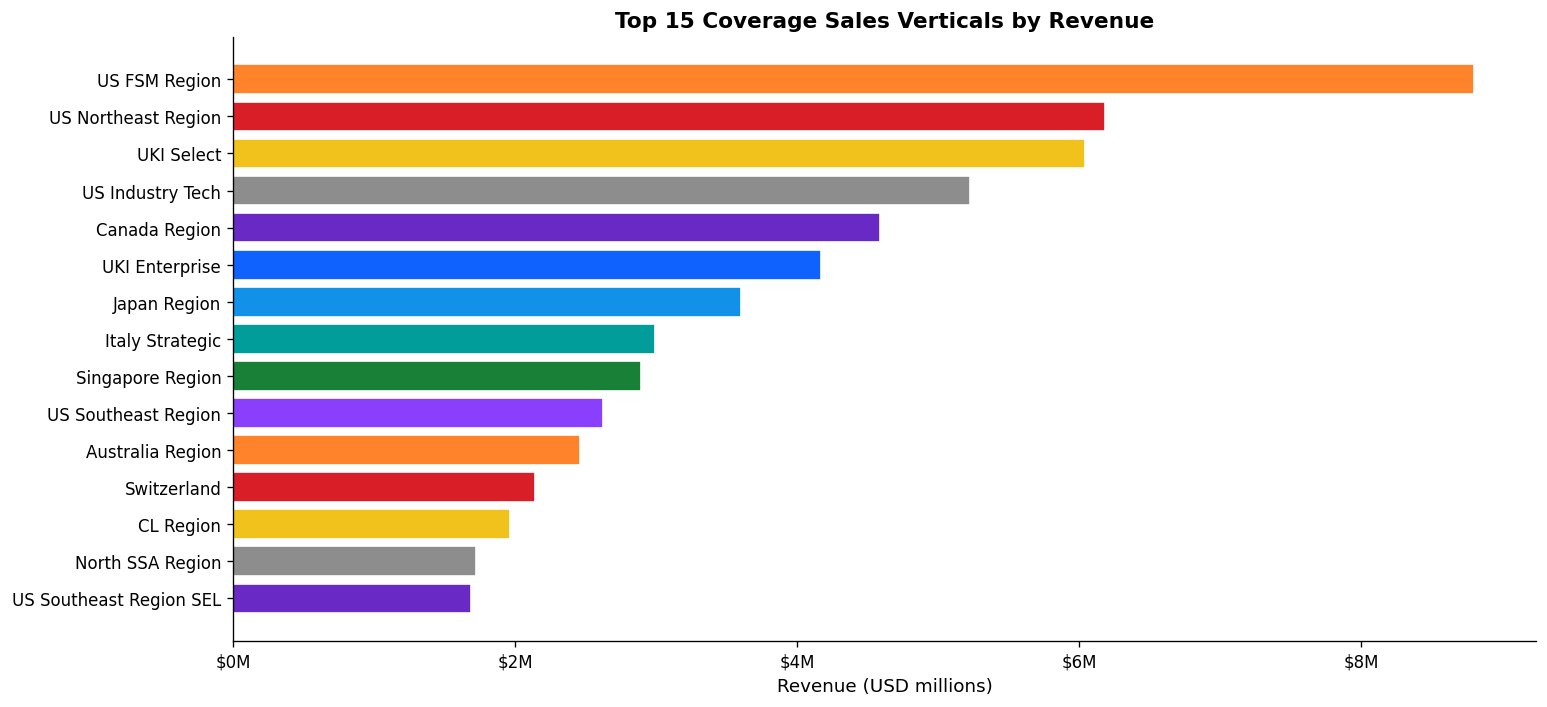

Note: Standard industry columns (SIC/NAICS) are empty in this data extract.
Coverage Sales Vertical is the closest available segment proxy.


,Revenue,Share
Coverage Sales Vertical,,
US FSM Region,"$8,800,612",15.4%
US Northeast Region,"$6,187,076",10.8%
UKI Select,"$6,043,939",10.6%
US Industry Tech,"$5,229,708",9.2%
Canada Region,"$4,592,077",8.0%
UKI Enterprise,"$4,172,633",7.3%
Japan Region,"$3,600,920",6.3%
Italy Strategic,"$2,991,106",5.2%
Singapore Region,"$2,892,721",5.1%


In [13]:
# Note: Standard industry classification columns are not populated in this extract.
# Using 'Coverage Sales Vertical' as the closest available geographic-segment proxy.

vert_rev = (
    df[df['Coverage Sales Vertical'].notna() &
       (df['Coverage Sales Vertical'].str.strip() != '') &
       (df['Coverage Sales Vertical'] != 'nan')]
    .groupby('Coverage Sales Vertical')['Rev Act @ PC']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(vert_rev.index[::-1], vert_rev.values[::-1] / 1e6,
        color=PALETTE[:len(vert_rev)][::-1], edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_title('Top 15 Coverage Sales Verticals by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (USD millions)')
plt.tight_layout()
plt.show()

print('Note: Standard industry columns (SIC/NAICS) are empty in this data extract.')
print('Coverage Sales Vertical is the closest available segment proxy.')
display(
    vert_rev.rename('Revenue').to_frame()
    .assign(Share=lambda d: (d['Revenue'] / d['Revenue'].sum() * 100).round(1))
    .style.format({'Revenue': '${:,.0f}', 'Share': '{:.1f}%'})
)

## 11  Key Takeaways

In [14]:
# Compute summary stats for the takeaways cell
total        = df['Rev Act @ PC'].sum()
saas_pct     = df[df['On-prem or SaaS'] == 'SaaS']['Rev Act @ PC'].sum() / total * 100
americas_pct = df[df['Geography'] == 'Americas']['Rev Act @ PC'].sum() / total * 100
top1_name    = top_customers.index[0]
top1_pct     = top_customers.iloc[0] / total * 100
user_pct     = vm_rev.get('Per Authorized User', 0) / total * 100

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║          OpenPages Revenue — Key Takeaways                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Total Revenue (all rows)    : ${total:>12,.0f}               ║
║                                                                  ║
║  1. SaaS dominates: {saas_pct:.1f}% of revenue is SaaS-based.       ║
║     On-prem is declining as migration to Cloud continues.        ║
║                                                                  ║
║  2. Americas leads geographically at {americas_pct:.1f}% of revenue.   ║
║     EMEA is a strong #2 (~{df[df['Geography']=='EMEA']['Rev Act @ PC'].sum()/total*100:.1f}%); APAC + Japan still                ║
║     represent growth headroom.                                   ║
║                                                                  ║
║  3. Top customer ({top1_name[:25]:<25}) accounts    ║
║     for {top1_pct:.1f}% of revenue — concentration risk to monitor.  ║
║                                                                  ║
║  4. 'Per Authorized User' is the top pricing metric ({user_pct:.1f}%),║
║     followed by Per Application and Per Instance.                ║
║                                                                  ║
║  5. Revenue shows strong growth from 2024 Q1 through 2025 Q3/Q4.║
║     2026 rows are mainly future-period bookings (annuity).       ║
║                                                                  ║
║  6. Financial services (Banking, Insurance) dominate industry   ║
║     mix — consistent with OpenPages' GRC positioning.           ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          OpenPages Revenue — Key Takeaways                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Total Revenue (all rows)    : $  71,438,393               ║
║                                                                  ║
║  1. SaaS dominates: 81.7% of revenue is SaaS-based.       ║
║     On-prem is declining as migration to Cloud continues.        ║
║                                                                  ║
║  2. Americas leads geographically at 48.4% of revenue.   ║
║     EMEA is a strong #2 (~36.9%); APAC + Japan still                ║
║     represent growth headroom.                                   ║
║                                                                  ║
║  3. Top customer (THE DUN & BRADSTREET CORP) accounts    ║
║     for 7.0% of revenue — concentration risk to monitor.  